# 📦 **STEP 0: Install Dependencies**

---

### Purpose
This cell installs all the required Python libraries needed for our Word2Vec implementation.

### Libraries to be installed:
- **numpy** - For numerical computations and matrix operations
- **matplotlib** - For creating visualizations and plots
- **scikit-learn** - For PCA (dimensionality reduction) to visualize high-dimensional embeddings in 2D

_💡 Note: Run this cell first if you don't have these libraries installed._


In [1]:
# Install required dependencies
%pip install numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


# 🔧 **STEP 1: Import Libraries & Set Random Seeds**

---

### Purpose
This cell imports all necessary libraries and sets random seeds for reproducibility.

### What happens here:
- **numpy** - Used for mathematical operations on vectors and matrices
- **matplotlib.pyplot** - Used to create scatter plots of word embeddings
- **collections.defaultdict** - For efficient dictionary operations
- **random** - For shuffling training data
- **Random seeds (42)** - Ensures consistent results across runs

_💡 Setting seeds means you'll get the same results every time you run the notebook!_


In [2]:
# Simple Word2Vec Implementation with Visualization
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


# 📚 **STEP 2: Create Training Corpus**

---

### Purpose
This cell defines our training dataset - a corpus of 100 sentences with a limited, focused vocabulary.

### Corpus Characteristics:
- **Size:** 100 sentences
- **Vocabulary Focus:** Limited to ~40-50 unique words
- **Themes:**
  - Animals: cat, dog, bird
  - Actions: sits, plays, runs, sleeps, eats, drinks, flies
  - Places: park, tree, house, garden, sky
  - Objects: ball, mat, food, water
  - Descriptors: red, blue, soft, big, small, happy

_💡 A limited vocabulary helps create clearer, more interpretable embeddings for visualization!_


In [3]:
# Sample corpus - 100 sentences with limited vocabulary
# Vocabulary focused on: animals (cat, dog, bird), actions (sits, plays, runs, sleeps, eats),
# places (park, tree, house, garden), and objects (ball, mat, food, water)
corpus = [
    # Cat sentences
    "the cat sits on the mat",
    "the cat plays with the ball",
    "the cat sleeps in the house",
    "the cat runs in the garden",
    "the cat eats the food",
    "the cat drinks the water",
    "the cat climbs the tree",
    "the cat loves the ball",
    "the cat sits by the tree",
    "the cat plays in the garden",
    # Dog sentences
    "the dog plays in the park",
    "the dog sits in the park",
    "the dog runs in the park",
    "the dog sleeps in the house",
    "the dog eats the food",
    "the dog drinks the water",
    "the dog loves the ball",
    "the dog plays with the ball",
    "the dog runs in the garden",
    "the dog sits on the mat",
    # Bird sentences
    "the bird flies in the sky",
    "the bird sits on the tree",
    "the bird sings in the tree",
    "the bird flies to the tree",
    "the bird eats the food",
    "the bird drinks the water",
    "the bird loves the tree",
    "the bird flies in the garden",
    "the bird sits in the park",
    "the bird sings in the park",
    # Cat and dog together
    "the cat and dog are friends",
    "the cat and dog play together",
    "the cat and dog eat food",
    "the cat and dog run together",
    "the cat and dog sleep together",
    "the cat and dog sit together",
    "the cat and dog love playing",
    "the cat and dog drink water",
    "the cat and dog are happy",
    "the cat and dog share food",
    # Objects and descriptions
    "the ball is red and round",
    "the mat is soft and warm",
    "the sky is blue and clear",
    "the house is big and warm",
    "the garden is green and beautiful",
    "the tree is tall and strong",
    "the park is big and green",
    "the food is fresh and tasty",
    "the water is clean and cold",
    "the ball is small and round",
    # Action combinations
    "the cat runs and plays",
    "the dog sleeps and eats",
    "the bird flies and sings",
    "the cat sits and sleeps",
    "the dog runs and jumps",
    "the bird eats and drinks",
    "the cat plays and runs",
    "the dog sits and waits",
    "the bird flies and lands",
    "the cat climbs and jumps",
    # Location variations
    "the cat is in the house",
    "the dog is in the park",
    "the bird is in the sky",
    "the ball is in the garden",
    "the mat is in the house",
    "the tree is in the park",
    "the food is in the house",
    "the water is in the house",
    "the cat is in the garden",
    "the dog is in the garden",
    # More interactions
    "the cat sees the bird",
    "the dog chases the ball",
    "the bird watches the cat",
    "the cat catches the ball",
    "the dog finds the food",
    "the bird loves the sky",
    "the cat enjoys the sun",
    "the dog plays with cat",
    "the bird flies above tree",
    "the cat rests on mat",
    # Additional variety
    "the happy cat plays",
    "the big dog runs",
    "the small bird sings",
    "the red ball rolls",
    "the soft mat waits",
    "the tall tree stands",
    "the green garden grows",
    "the blue sky shines",
    "the warm house protects",
    "the fresh food smells",
    # More contextual sentences
    # "cat and bird are different",
    # "dog and cat are pets",
    # "bird flies but cat climbs",
    # "dog runs but bird flies",
    # "cat sleeps on soft mat",
    # "dog plays with red ball",
    # "bird sits on tall tree",
    # "cat drinks clean water",
    # "dog eats fresh food",
    # "bird sings happy song",
    # final set of sentences
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden",
    "Rama marries Sita in the garden"
]

print(f"Corpus size: {len(corpus)} sentences")
print(f"\nSample sentences:")
for i, sentence in enumerate(corpus[:5]):
    print(f"{i+1}. {sentence}")


Corpus size: 100 sentences

Sample sentences:
1. the cat sits on the mat
2. the cat plays with the ball
3. the cat sleeps in the house
4. the cat runs in the garden
5. the cat eats the food


# 🔤 **STEP 3: Preprocess Corpus & Build Vocabulary**

---

### Purpose
This cell preprocesses the raw text corpus and builds the vocabulary needed for training.

### Processing Steps:
1. **Tokenization:** Split each sentence into individual words
2. **Lowercasing:** Convert all words to lowercase for consistency
3. **Vocabulary Building:** Extract all unique words from the corpus
4. **Index Mapping:** Create bidirectional mappings:
   - `word_to_idx`: Word → Index (e.g., "cat" → 5)
   - `idx_to_word`: Index → Word (e.g., 5 → "cat")

_💡 These mappings allow us to convert words to numbers (for math) and back to words (for display)!_


In [4]:
# Preprocessing: tokenize and build vocabulary
def preprocess(corpus):
    tokenized = [sentence.lower().split() for sentence in corpus]
    
    # Build vocabulary
    vocab = set()
    for sentence in tokenized:
        vocab.update(sentence)
    
    vocab = sorted(list(vocab))
    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}
    
    return tokenized, vocab, word_to_idx, idx_to_word

tokenized_corpus, vocab, word_to_idx, idx_to_word = preprocess(corpus)

print(f"Vocabulary size: {len(vocab)}")
print(f"\nVocabulary: {vocab}")


Vocabulary size: 80

Vocabulary: ['above', 'and', 'are', 'ball', 'beautiful', 'big', 'bird', 'blue', 'by', 'cat', 'catches', 'chases', 'clean', 'clear', 'climbs', 'cold', 'dog', 'drink', 'drinks', 'eat', 'eats', 'enjoys', 'finds', 'flies', 'food', 'fresh', 'friends', 'garden', 'green', 'grows', 'happy', 'house', 'in', 'is', 'jumps', 'lands', 'love', 'loves', 'marries', 'mat', 'on', 'park', 'play', 'playing', 'plays', 'protects', 'rama', 'red', 'rests', 'rolls', 'round', 'run', 'runs', 'sees', 'share', 'shines', 'sings', 'sit', 'sita', 'sits', 'sky', 'sleep', 'sleeps', 'small', 'smells', 'soft', 'stands', 'strong', 'sun', 'tall', 'tasty', 'the', 'to', 'together', 'tree', 'waits', 'warm', 'watches', 'water', 'with']


# 🎯 **STEP 4: Generate Training Data (Skip-Gram Pairs)**

---

### Purpose
This cell generates training pairs using the **Skip-Gram** approach - the core of Word2Vec.

### How Skip-Gram Works:
- **Target Word:** The current word we're processing
- **Context Words:** Words surrounding the target within a window
- **Window Size:** 2 (looks 2 words before and 2 words after)

### Example:
```
Sentence: "the CAT sits on the"
Target: "cat" → Context: ["the", "sits", "on"]
Creates pairs: (cat → the), (cat → sits), (cat → on)
```

_💡 Words appearing in similar contexts will get similar embeddings!_


In [5]:
# Generate training data using skip-gram approach (context window = 2)
def generate_training_data(tokenized_corpus, word_to_idx, window_size=2):
    training_data = []
    
    for sentence in tokenized_corpus:
        for i, target_word in enumerate(sentence):
            target_idx = word_to_idx[target_word]
            
            # Get context words within window
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            
            for j in range(start, end):
                if j != i:
                    context_idx = word_to_idx[sentence[j]]
                    training_data.append((target_idx, context_idx))
    
    return training_data

training_data = generate_training_data(tokenized_corpus, word_to_idx)

print(f"Training pairs generated: {len(training_data)}")
print("\nFirst 10 training pairs (target -> context):")
for i, (target, context) in enumerate(training_data[:10]):
    print(f"{idx_to_word[target]} -> {idx_to_word[context]}")


Training pairs generated: 1600

First 10 training pairs (target -> context):
the -> cat
the -> sits
cat -> the
cat -> sits
cat -> on
sits -> the
sits -> cat
sits -> on
sits -> the
on -> cat


# 🧠 **STEP 5: Implement Word2Vec Neural Network**

---

### Purpose
This cell implements a simple neural network for Word2Vec training from scratch.

### Neural Network Architecture:
- **Input Layer:** One-hot encoded word (vocabulary size)
    - One-hot encoded vectors Example:
        - "cat" → [1, 0, 0]
        - "dog" → [0, 1, 0]
        - "fish" → [0, 0, 1]
- **Hidden Layer:** Word embeddings (10 dimensions per word)
- **Output Layer:** Probability distribution over vocabulary (softmax)

### Key Components:
- **W1 (Input → Hidden):** The actual word embeddings we want to learn!
- **W2 (Hidden → Output):** Weights for predicting context words
- **Forward Pass:** Get embedding → predict context word probability
- **Backward Pass:** Update weights based on prediction error
- **Training Loop:** Iteratively improve embeddings over multiple epochs

_💡 The magic happens in W1 - these become our word vectors!_


In [6]:
# Simple Word2Vec Model Implementation
class SimpleWord2Vec:
    def __init__(self, vocab_size, embedding_dim=10):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Initialize embeddings randomly (small values)
        self.W1 = np.random.uniform(-0.5, 0.5, (vocab_size, embedding_dim))  # Input embeddings
        self.W2 = np.random.uniform(-0.5, 0.5, (embedding_dim, vocab_size))  # Output embeddings
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x))  # Numerical stability
        return exp_x / exp_x.sum()
    
    def forward(self, target_idx):
        # Get embedding for target word
        h = self.W1[target_idx]  # Hidden layer (embedding)
        
        # Output layer
        u = np.dot(h, self.W2)
        y_pred = self.softmax(u)
        
        return h, y_pred
    
    def backward(self, target_idx, context_idx, y_pred, h, learning_rate=0.01):
        # Create one-hot vector for context word
        y_true = np.zeros(self.vocab_size)
        y_true[context_idx] = 1
        
        # Calculate error
        error = y_pred - y_true
        
        # Update weights
        dW2 = np.outer(h, error)
        dW1 = np.dot(error, self.W2.T)
        
        self.W2 -= learning_rate * dW2
        self.W1[target_idx] -= learning_rate * dW1
    
    def train(self, training_data, epochs=100, learning_rate=0.01, verbose=True):
        loss_history = []
        for epoch in range(epochs):
            loss = 0
            random.shuffle(training_data)
            
            for target_idx, context_idx in training_data:
                h, y_pred = self.forward(target_idx)
                
                # Calculate loss (cross-entropy)
                loss += -np.log(y_pred[context_idx] + 1e-10)
                
                # Backpropagation
                self.backward(target_idx, context_idx, y_pred, h, learning_rate)

            loss_history.append(loss)
            if verbose and (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")

        # After training is complete, plot the loss
        plt.figure(figsize=(8, 5))
        plt.plot(loss_history, label='Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training Loss over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

        return loss_history
    
    def get_embeddings(self):
        return self.W1

# Initialize model
embedding_dim = 10
model = SimpleWord2Vec(len(vocab), embedding_dim)

print(f"Model initialized with {len(vocab)} words and {embedding_dim}-dimensional embeddings")


Model initialized with 80 words and 10-dimensional embeddings


# 📊 **STEP 6: Visualize INITIAL Embeddings (Before Training)**

---

### Purpose
This cell visualizes the **random, untrained** word embeddings before any learning has occurred.

### What's Happening:
- **Snapshot:** Saves a copy of initial random embeddings (IMPORTANT!)
- **PCA Reduction:** Reduces 10D embeddings → 2D for visualization
- **Scatter Plot:** Shows each word as a point in 2D space

### What to Expect:
- ❌ **Random Distribution:** Words scattered with no pattern
- ❌ **No Semantic Meaning:** Similar words (cat/dog) are far apart
- ❌ **No Clusters:** No grouping by meaning or function

_💡 We use .copy() to preserve these initial values before training modifies them!_


Visualizing INITIAL (random) embeddings...
Notice: Words are randomly distributed with no semantic relationships



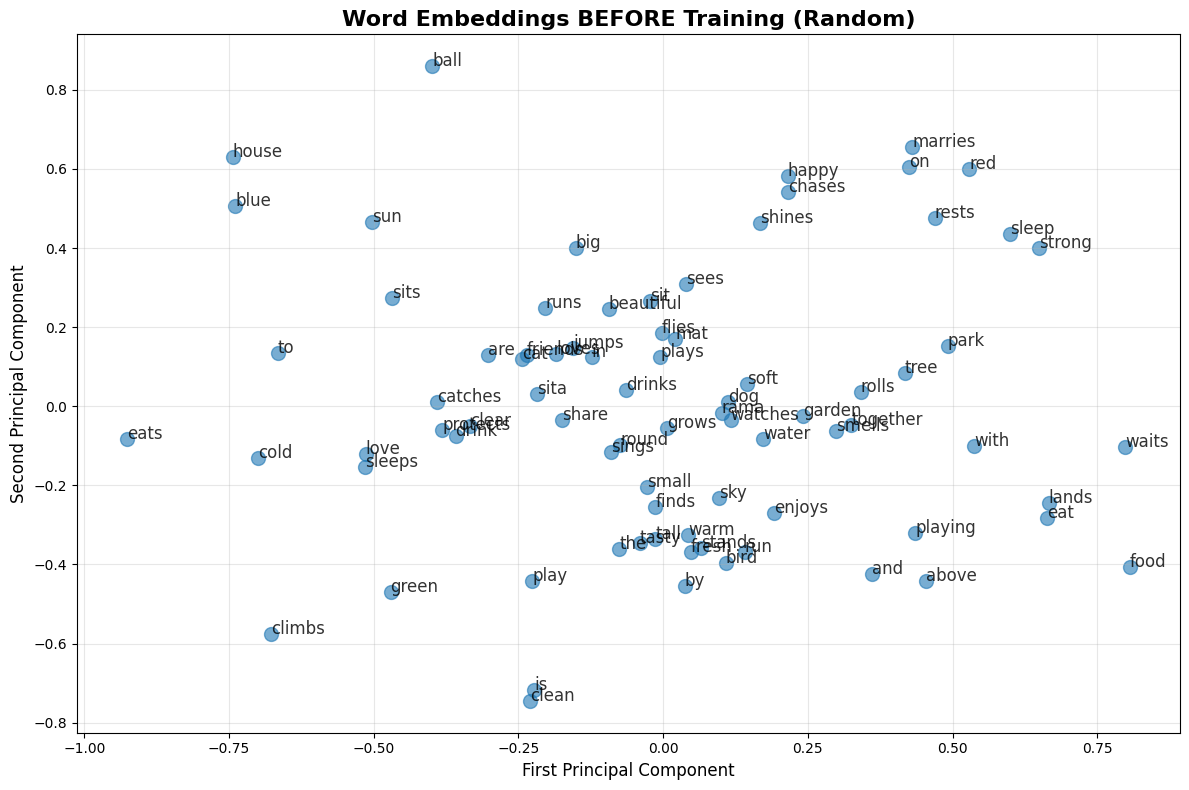

In [7]:
# Visualize embeddings BEFORE training using PCA
from sklearn.decomposition import PCA

def visualize_embeddings(embeddings, vocab, title="Word Embeddings"):
    # Reduce to 2D using PCA
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Create plot
    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=100)
    
    # Add labels for each word
    for i, word in enumerate(vocab):
        plt.annotate(word, 
                    (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    fontsize=12,
                    alpha=0.8)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('First Principal Component', fontsize=12)
    plt.ylabel('Second Principal Component', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Get initial embeddings (before training) - IMPORTANT: Make a copy!
initial_embeddings = model.get_embeddings().copy()

print("Visualizing INITIAL (random) embeddings...")
print("Notice: Words are randomly distributed with no semantic relationships\n")
visualize_embeddings(initial_embeddings, vocab, "Word Embeddings BEFORE Training (Random)")


# 🚀 **STEP 7: Train the Word2Vec Model**

---

### Purpose
This cell trains the neural network to learn meaningful word embeddings from the corpus.

### Training Configuration:
- **Epochs:** 200 iterations through the entire dataset
- **Learning Rate:** 0.05 (controls how fast the model learns)
- **Objective:** Predict context words from target words
- **Loss Function:** Cross-entropy (measures prediction accuracy)

### What's Happening During Training:
1. For each (target, context) pair:
   - Look up the target word's embedding
   - Predict the probability of each context word
   - Calculate error (how wrong was the prediction)
   - Adjust embeddings to reduce error
2. Repeat for all pairs, multiple times (epochs)
3. Gradually, similar words develop similar embeddings!

_⏱️ This may take 30-60 seconds. Watch the loss decrease over time!_


Training the Word2Vec model...
Epoch 20/200, Loss: 4278.0317
Epoch 40/200, Loss: 4193.8944
Epoch 60/200, Loss: 4163.1966
Epoch 80/200, Loss: 4159.8656
Epoch 100/200, Loss: 4144.0520
Epoch 120/200, Loss: 4136.7526
Epoch 140/200, Loss: 4137.3078
Epoch 160/200, Loss: 4124.2620
Epoch 180/200, Loss: 4141.1167
Epoch 200/200, Loss: 4123.9885


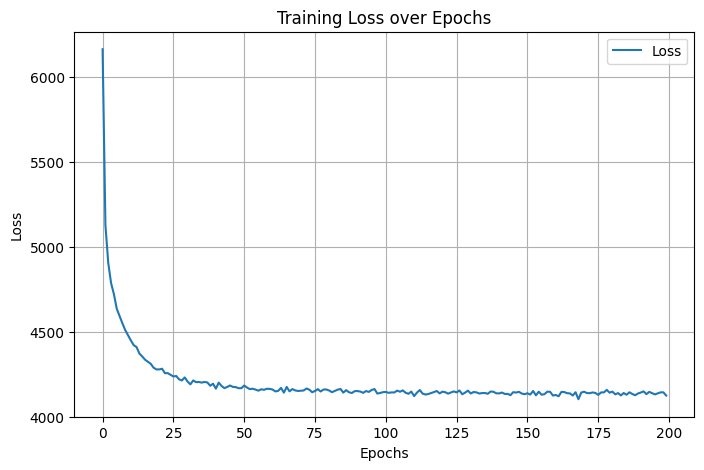

Training complete!


In [8]:
# Train the model
print("Training the Word2Vec model...")
print("=" * 50)
model.train(training_data, epochs=200, learning_rate=0.05, verbose=True)
print("=" * 50)
print("Training complete!")


# 📊 **STEP 8: Visualize TRAINED Embeddings (After Training)**

---

### Purpose
This cell visualizes the **learned word embeddings** after training is complete.

### What's Happening:
- **Extract Embeddings:** Get the trained W1 weights from the model
- **PCA Reduction:** Reduces 10D embeddings → 2D for visualization
- **Scatter Plot:** Shows how words are now positioned in semantic space

### What to Expect:
- ✅ **Semantic Clusters:** Similar words group together
- ✅ **Animal Cluster:** cat, dog, bird should be close
- ✅ **Action Cluster:** sits, plays, runs, sleeps nearby
- ✅ **Place Cluster:** park, house, garden, tree together

_💡 Compare this with the previous plot - the difference shows what the model learned!_


Visualizing TRAINED embeddings...
Notice: Similar words (cat/dog, sits/plays) should now be closer together!



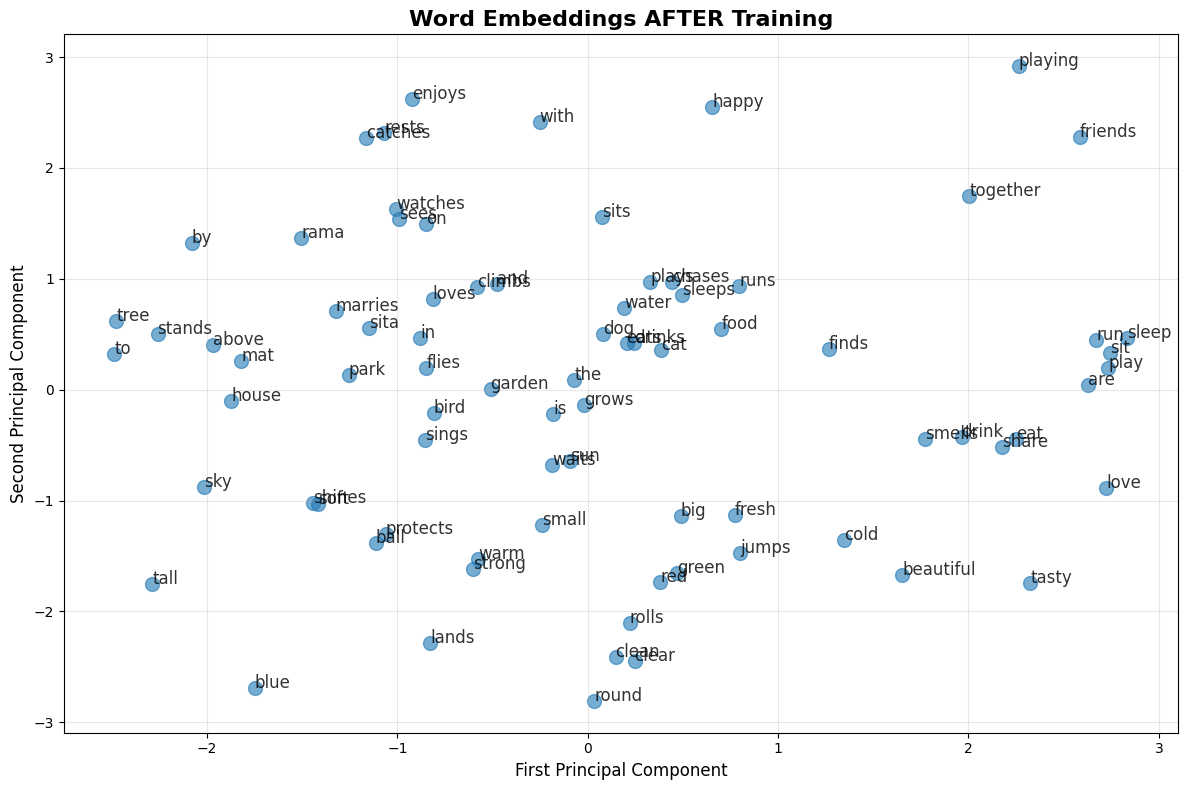

In [9]:
# Visualize embeddings AFTER training
trained_embeddings = model.get_embeddings()

print("Visualizing TRAINED embeddings...")
print("Notice: Similar words (cat/dog, sits/plays) should now be closer together!\n")
visualize_embeddings(trained_embeddings, vocab, "Word Embeddings AFTER Training")


# 🔍 **STEP 9: Find Similar Words Using Cosine Similarity**

---

### Purpose
This cell finds similar words by measuring the **cosine similarity** between word embeddings.

### How Cosine Similarity Works:
- **Formula:** Measures the angle between two vectors
- **Range:** -1 (opposite) to +1 (identical direction)
- **Interpretation:** Higher values = more similar words

### What This Cell Does:
1. Takes a query word (e.g., "cat")
2. Compares its embedding with all other words
3. Ranks words by similarity score
4. Returns top 5 most similar words

### Expected Results:
```
"cat" → similar to: dog, bird, plays
"dog" → similar to: cat, park, plays
"park" → similar to: garden, tree, sky
```

_💡 This demonstrates that the embeddings captured semantic relationships!_


In [10]:
# Find similar words using cosine similarity
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

def find_similar_words(word, embeddings, vocab, word_to_idx, top_k=5):
    if word not in word_to_idx:
        return f"Word '{word}' not in vocabulary"
    
    word_idx = word_to_idx[word]
    word_vec = embeddings[word_idx]
    
    similarities = []
    for idx, vec in enumerate(embeddings):
        if idx != word_idx:
            sim = cosine_similarity(word_vec, vec)
            similarities.append((vocab[idx], sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test with some example words
test_words = ["cat", "dog", "park", "sits"]

print("Finding similar words based on learned embeddings:")
print("=" * 60)
for word in test_words:
    print(f"\nMost similar words to '{word}':")
    similar = find_similar_words(word, trained_embeddings, vocab, word_to_idx)
    for similar_word, similarity in similar:
        print(f"  {similar_word}: {similarity:.4f}")


Finding similar words based on learned embeddings:

Most similar words to 'cat':
  sleeps: 0.8037
  sun: 0.7244
  bird: 0.6727
  plays: 0.6109
  jumps: 0.5959

Most similar words to 'dog':
  climbs: 0.7115
  plays: 0.6880
  sleeps: 0.6725
  by: 0.6400
  happy: 0.5973

Most similar words to 'park':
  house: 0.9271
  garden: 0.8196
  mat: 0.7304
  is: 0.6420
  sita: 0.6418

Most similar words to 'sits':
  rests: 0.8095
  flies: 0.7372
  on: 0.6535
  watches: 0.6444
  eats: 0.6343


# 🎨 **STEP 10: Side-by-Side Comparison (Before vs After)**

---

### Purpose
This cell creates a **side-by-side visualization** comparing embeddings before and after training.

### Visualization Features:
- **Left Plot (Blue):** Random initial embeddings - scattered, no patterns
- **Right Plot (Red):** Trained embeddings - semantic clustering visible
- **Separate PCA:** Each plot uses its own PCA transformation
- **Same Words:** Shows how each word's position changed

### What to Look For:

**Before (Left):**
- ❌ Random scattered points
- ❌ No semantic groupings
- ❌ Similar words far apart

**After (Right):**
- ✅ Clear clusters forming
- ✅ Animals grouped together
- ✅ Actions grouped together
- ✅ Similar words close together

_🎉 This is the power of Word2Vec - learning semantic relationships from context!_


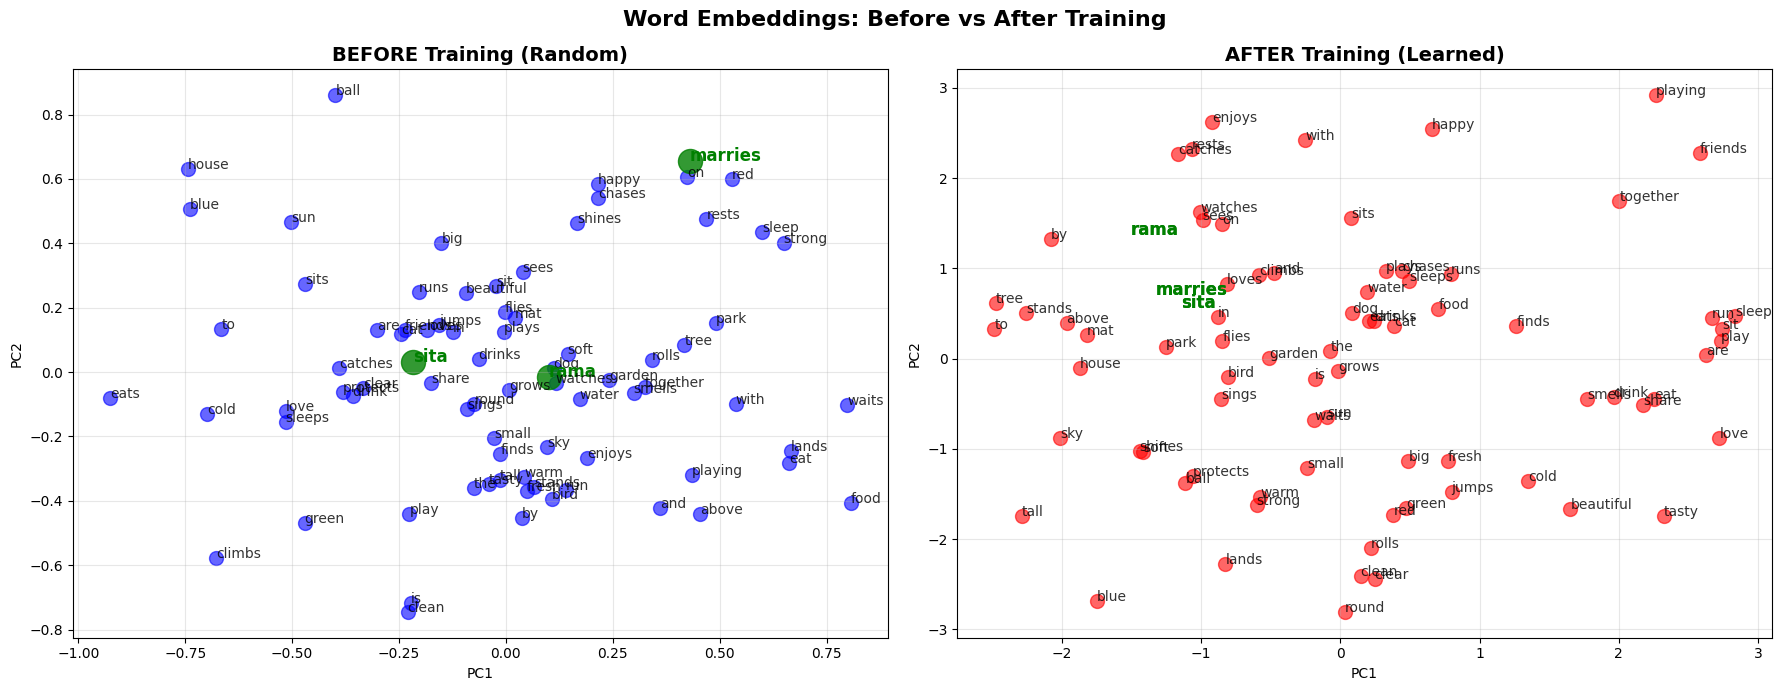


🎉 Notice how the trained embeddings (right) show semantic clustering!
Similar words like 'cat' and 'dog', or 'sits' and 'plays' are now closer together.
words highlighted in GREEN with BIGGER bullets and BOLD text: rama, sita, marries


In [15]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Define words to highlight in green
highlight_words = ['rama', 'sita', 'marries']
# highlight_words = ['cat', 'dog', 'bird', 'sits', 'plays', 'park']

# Before training - use separate PCA instance
pca_before = PCA(n_components=2)
initial_2d = pca_before.fit_transform(initial_embeddings)

for i, word in enumerate(vocab):
    if word not in highlight_words:
        ax1.scatter(initial_2d[i, 0], initial_2d[i, 1], alpha=0.6, s=100, c='blue')

for i, word in enumerate(vocab):
    if word in highlight_words:
        ax1.scatter(initial_2d[i, 0], initial_2d[i, 1], alpha=0.8, s=300, c='green')

#add labels
for i, word in enumerate(vocab):
    if word in highlight_words: 
        ax1.annotate(word, (initial_2d[i, 0], initial_2d[i, 1]), fontsize=12, fontweight='bold', alpha=1.0, color='green')
    else:  
        ax1.annotate(word, (initial_2d[i, 0], initial_2d[i, 1]), fontsize=10, alpha=0.8)    
    
ax1.set_title('BEFORE Training (Random)', fontsize=14, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, alpha=0.3)

# After training - use separate PCA instance
pca_after = PCA(n_components=2)
trained_2d = pca_after.fit_transform(trained_embeddings)

for i, word in enumerate(vocab):
    if word not in highlight_words:
        ax2.scatter(trained_2d[i, 0], trained_2d[i, 1], alpha=0.6, s=100, c='red')

for i, word in enumerate(vocab):
    if word in highlight_words:
        ax2.annotate(word, (trained_2d[i, 0], trained_2d[i, 1]), fontsize=12, fontweight='bold', alpha=1.0, color='green')

#add labels
for i, word in enumerate(vocab):
    if word in highlight_words: 
        ax2.annotate(word, (trained_2d[i, 0], trained_2d[i, 1]), fontsize=12, fontweight='bold', alpha=1.0, color='green')
    else:  
        ax2.annotate(word, (trained_2d[i, 0], trained_2d[i, 1]), fontsize=10, alpha=0.8, color='black')

ax2.set_title('AFTER Training (Learned)', fontsize=14, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(True, alpha=0.3)

plt.suptitle('Word Embeddings: Before vs After Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎉 Notice how the trained embeddings (right) show semantic clustering!")
print("Similar words like 'cat' and 'dog', or 'sits' and 'plays' are now closer together.")
print(f"words highlighted in GREEN with BIGGER bullets and BOLD text: {', '.join(highlight_words)}")
